# Análise de Robustez de Portfólios com Sharpe Máximo

#### O objetivo desse notebook é analisar a performance/capacidade preditiva de portfólios com sharpe ótimo. Mais precisamente, foi estimada uma matriz de covariança $\Sigma$ e o retorno esperado $\mu$ usando suas versões amostrais usando um período de lookback de 126 dias

#### Para cada dia do período contemplado (2021/01/1 - 2024/12/30), foi encontrado o portfolio de máximo sharpe usando os estimadores mencionados.

#### Após isso, foi calculado a variança , o retorno acumulado e o sharpe realizados após a compra do portfólio, na esperança de simular a experiência de um investidor que tenha, em algum ponto do passado, comprado o portfólio ótimo.

### Bibliotecas

In [1]:

import numpy as np
from scipy.optimize import minimize
import statsmodels.api as sm

import matplotlib.pyplot as plt
from datetime import datetime,timedelta,date
import pandas as pd

import yfinance as yf

import warnings
import itertools as iter


ModuleNotFoundError: No module named 'yfinance'

## Importação e Tratamento de Dados

In [ ]:
path = r'C:\\Users\\Vitor\\Desktop\\Limfe\\acoes_ibov_9012025.csv'
acoes_do_ibov = pd.read_csv(path)

tickers = acoes_do_ibov['IBOV - Carteira do Dia 09/01/25'][1:-2].to_list()

d1 = date.fromisoformat('2024-12-30')
d2 = date.fromisoformat('2021-01-01')

data_final = d1 #datetime.now()
data_inicial = d2 #data_final - timedelta(days=1440)


dados0 = yf.download(tickers=tickers[:],
            start=data_inicial,
            end=data_final,
            interval='1d',
            keepna=True,
            auto_adjust=False
               )



In [4]:
dados = dados0.copy()
close0 = dados['Close']

In [256]:


close = close0.copy()

# dicionario no formato {ticker : quantidade de dados faltantes} 
nan_tickers = { ticker : close[ticker].isna().sum()  for ticker in tickers}


tol = 50 
for name in tickers: # remove os tickers com dados faltantes
    if nan_tickers[name] > tol:
        close.drop(columns=name,inplace=True)



close.interpolate(method='spline',
                  order=3,
                  limit = 55,
                  limit_direction='both',
                  inplace=True)

returns = close.pct_change()
cum_return = (1 + returns).cumprod() - 1

## Backtest 

#### Calculamos primeiro as matrizes de covarianca móvel $\Sigma_t$ e o retorno móvel $\mu_t$, junto do portfolio de maximo sharpe $P_t$ (também móvel)  

In [258]:
rolling_cov_matrix = returns.rolling(126).cov()
rolling_mean_return = returns.rolling(126).mean()

In [259]:
def sharpe(weights,mean_return,cov_matrix):
    
    port_return = weights @ mean_return 
    port_vol = np.sqrt(weights @ cov_matrix @ weights) 
    sharpe_ratio = port_return / port_vol # tecnicamente, precisariamos levar em conta a livre de risco
    return -sharpe_ratio

n_ativos = len(close.columns)
initial_weights = np.array([1/n_ativos] * n_ativos) # alocação igual para todos os ativos, para inicializar o algoritmo de otimização
limits = tuple((0,0.9) for x in range(n_ativos)) # alocação não pode ser nem menor de 5% e nem maior de 90% 
constraint = {'type' : 'eq' , 'fun' : lambda pesos: np.sum(pesos) - 1} # soma dos pesos tem que ser igual a 1

def markowitz(mean_return,cov_matrix):
    
    optimizable_sharpe = lambda w: sharpe(w,mean_return,cov_matrix)
    max_sharpe = minimize(
    fun=optimizable_sharpe,
    x0=initial_weights,
    method='SLSQP',
    bounds=limits,
    constraints=constraint
                ) # acha o portfolio com o maior índice de sharpe diário

    pesos_otimos = max_sharpe.x
    sharpe_otimo = max_sharpe.fun
    return pesos_otimos,sharpe_otimo

In [262]:
df_index = rolling_mean_return.iloc[126:].index
df_columns = list(returns.columns) + ['Sharpe']
df = pd.DataFrame(index=df_index,columns=df_columns)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    
    for date in df_index:
        mean_return = rolling_mean_return.loc[date]
        cov_matrix = rolling_cov_matrix.loc[date]
    
        pesos_ideais,sharpe_max = markowitz(mean_return,cov_matrix)
        df_row = np.concatenate([np.round(pesos_ideais,4),[sharpe_max]])
        df.loc[date] = df_row

df['Sharpe'] *= -1

In [359]:
df # Data frame com pesos ótimos em cada data

,ABEV3.SA,ALOS3.SA,ASAI3.SA,AZUL4.SA,AZZA3.SA,B3SA3.SA,BBAS3.SA,BBDC3.SA,BBDC4.SA,BBSE3.SA,...,UGPA3.SA,USIM5.SA,VALE3.SA,VAMO3.SA,VBBR3.SA,VIVA3.SA,VIVT3.SA,WEGE3.SA,YDUQ3.SA,Sharpe
Date,,,,,,,,,,,,,,,,,,,,,
2021-07-07,0.0,0.0,0.4159,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002,0.0,0.0,0.1792,0.0,0.0,0.0,0.0,0.0,0.506639
2021-07-08,0.0,0.0,0.4307,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0026,0.0,0.0,0.1818,0.0,0.0,0.0,0.0,0.0,0.491466
2021-07-12,0.0,0.0,0.4179,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0029,0.0,0.0,0.1878,0.0,0.0,0.0,0.0,0.0,0.49112
2021-07-13,0.0,0.0,0.4164,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0023,0.0,0.0,0.1824,0.0,0.0,0.0,0.0,0.0,0.487314
2021-07-14,0.0,0.0,0.4192,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0022,0.0,0.0,0.209,0.0,0.0,0.0,0.0,0.0,0.484931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-19,0.0644,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1809,0.0,0.251571
2024-12-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1753,0.0,0.236153
2024-12-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0232,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1361,0.0,0.228071


### Calculando a performance dos portfólios:

In [267]:
backtest_df = pd.DataFrame(columns=df_index,index=df_index)

iterable = [df_index,returns.columns]
index = pd.MultiIndex.from_product(iterable,names=['Data da Otimização',"Ativos"])
realized_matrices = pd.DataFrame(index=index,columns=returns.columns)

sharpe_ratios = pd.DataFrame(index=df_index,columns=['Sharpe Realizado'])

for date in df_index:
    historical_weights = df.drop(columns=['Sharpe']) 
    weights = historical_weights.loc[date] # pesos calculados na data

    # calcula retorno do portfólio a partir do dia que ele comprado
    period_returns = returns.loc[df_index] # retornos não nan
    period_returns.loc[:date] = 0 # zera retornos antes da data
    period_returns.loc[date:] = returns.loc[date:] 
    port_returns =  period_returns @ weights 
    backtest_df[date] = port_returns 

    portfolio_total_return = ((1 + port_returns).cumprod() - 1).iloc[-1] # retorno acumulado apos a compra
    
    realized_cov_matrix = returns.loc[date:].cov() 
    realized_matrices.loc[date] = realized_cov_matrix.values 

    port_vol = np.sqrt(weights @ realized_cov_matrix.values @ weights) # desvio padrão do portfolio apos a compra
    num_days = len(returns.loc[date:].index)
    port_sharpe = portfolio_total_return / (port_vol * np.sqrt(num_days))
    sharpe_ratios.loc[date] = port_sharpe
    

C:\Users\Vitor\anaconda3\Lib\site-packages\pandas\core\frame.py:10866: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
C:\Users\Vitor\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\Vitor\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


## Ánalise dos Resultados:

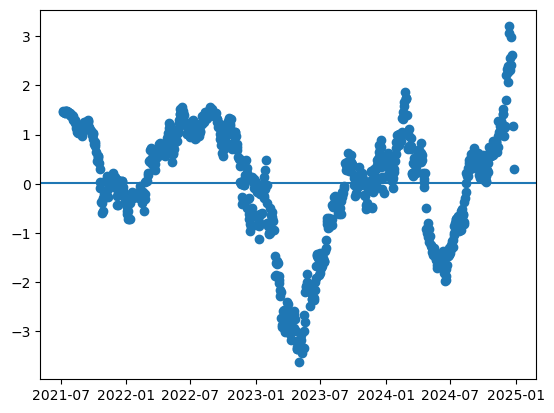

In [340]:
# calculando o sharpe realizado:

# Ánalise de Resíduos do sharpe do portfólio:
Residuals = df['Sharpe'] - sharpe_ratios['Sharpe Realizado']
MSE = (df['Sharpe'] - sharpe_ratios['Sharpe Realizado'])**2
mean_residual = Residuals.mean()
plt.axhline(y=mean_residual)
plt.scatter(df.index,Residuals)

#### Aqui, podemos ver que os resíduos do nosso modelo. i.e. o erro que ele comete na previsão do sharpe do portfólio é extremamente irregular.
#### Não apenas o erros estão com alta varianca, mas seu comportamento claramente depende do tempo.

### Uma conclusão que podemos tirar é que, se um investidor decide comprar o portfolio com sharpe ótimo, estará sujeito a erros de estimação grandes, que não se reduzirão para 0 ao longo do tempo e cuja magnitude depende do momento em que o investidor entra na posição.

### Naturalmente, deve se questionar se os estimadores usados são os melhores(poderíamos ter usado James Stein para calcular a média, por exemplo) e se o uso de mais dados não diminuirira o erro (nesse caso, teríamos que assumir que os retornos são Ergódicos, o que não necessariamente é verdade).